# Wildfire Risk Prediction

**Goal:** Train a model to predict a property's wildfire risk from its location, using Census socioeconomic data as input features and proximity to historical fire detections as the target.

**Business context:** *[TODO: Write 2-3 sentences on why this matters — insurance underwriting, real estate valuation, urban planning. Who would use this model and how?]*

**Approach:**
1. Generate geographically diverse property locations across CONUS
2. Enrich each property with ~850 Census ACS5 features (income, housing, demographics)
3. Calculate proximity to NASA FIRMS satellite fire detections (VIIRS)
4. Train XGBoost and RandomForest regressors to predict `nearest_fire_km`

**Limitations:** Current run uses county-level Census granularity due to hardware constraints. Tract or block-group level would capture finer neighborhood variation and likely improve results.

In [1]:
import pandas as pd
import load_wildfires
import load_census
import load_properties
import gis
import train
import visualize
import sqlalchemy as s

from pathlib import Path

from sql_funcs import SQL

from settings import PATH_DATA, TEST_SAMPLE_SIZE, TEST_N_ITER, TEST_CV,PATH_MODELS

TEST_MODE = False


In [2]:
SQL.kill_idle(True)
sql_obj = SQL()


kill_idle: terminated 8 connection(s)


# Load Properties

## Select Properties of Interest

Chosing 300000 properties randomly from US addresses. We will join relevant census data to these addresses. This will probably take awhile, so best to run it overnight.

We don't care about the address itself. We add a census identifier called the GEOID which based on the coordinate's state, county, and tract number.

Using a package that makes use of the [US Census Geocoder API](https://www.census.gov/programs-surveys/geography/technical-documentation/complete-technical-documentation/census-geocoder.html), requests can be in batches of 10,000.

https://pypi.org/project/random-address/

In [3]:
props = load_properties.Properties(sql_obj=sql_obj)
properties = props.get_properties_gpd()
cur_count = properties.shape[0]
desired_count = 300000
if cur_count < desired_count:
    diff = desired_count - cur_count
    print(f"Adding {diff} more properties...")
    props.add_random_properties_geo_first(diff)


300000 properties loaded.


# Load Features from US Census

2023 US Census Data

Using an API key, we will use the 'census' Python package to interact with the US Govermnent's census API.

In [4]:
import geopandas as gpd

MERGED_PARQUET = PATH_DATA / "merged_properties_census.parquet"

if MERGED_PARQUET.exists():
    print(f"Loading pre-merged data from {MERGED_PARQUET}...")
    combined_gdf = gpd.read_parquet(MERGED_PARQUET)
    print(f"Loaded {len(combined_gdf)} properties with census features.")
else:
    print("No pre-merged file found. Fetching census data from API...")
    census = load_census.CensusData(sql_obj=sql_obj, year=2023, granularity='county')
    combined_gdf = census.merge_census_info(properties)

combined_gdf.head()

Loading pre-merged data from data\merged_properties_census.parquet...
Loaded 300000 properties with census features.


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,B25091_014E,B25091_015E,B25091_016E,B25091_017E,B25091_018E,B25091_019E,B25091_020E,B25091_021E,B25091_022E,B25091_023E
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,0.149341,0.056879,0.033997,0.018242,0.014300,0.010256,0.009368,0.009005,0.024570,0.008219
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,0.097369,0.057454,0.015119,0.017236,0.028122,0.005745,0.000000,0.000000,0.008769,0.000000
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,0.250290,0.074493,0.043701,0.019570,0.014042,0.006302,0.011969,0.013102,0.039002,0.012328
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,0.153632,0.041678,0.019031,0.010505,0.007374,0.005141,0.002201,0.003925,0.011086,0.002309
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,0.156607,0.074042,0.040440,0.022883,0.012523,0.011175,0.007729,0.009077,0.024818,0.002424


# Load Wildfire Data

Wildfire detections from NASA's [FIRMS](https://firms.modaps.eosdis.nasa.gov/) system, using the Visible Infrared Imaging Radiometer Suite (VIIRS) aboard NOAA-21 and Suomi NPP satellites. Each detection is a ~375m pixel with fire radiative power (FRP) in megawatts.

Raw detections are clustered spatiotemporally (DBSCAN: 750m spatial, 3-day temporal) to deduplicate overlapping satellite passes into discrete fire events.

In [5]:
TARGETS_PARQUET = PATH_DATA / "targets_features.parquet"

if TARGETS_PARQUET.exists():
    print(f"Loading pre-computed targets+features from {TARGETS_PARQUET}...")
    targets_features = gpd.read_parquet(TARGETS_PARQUET)
    # Reconstruct proximity column list for drop_cols later
    census_cols = [c for c in targets_features.columns if c.startswith("B")]
    proximity_cols = [c for c in targets_features.columns
                      if c not in census_cols and c not in ["geometry", "geoid"]]
    print(f"Loaded {len(targets_features)} rows x {targets_features.shape[1]} cols "
          f"({len(proximity_cols)} proximity features)")
else:
    print("No pre-computed file found. Running wildfire ETL inline...")
    wildfires = load_wildfires.WildfireData(sql_obj=sql_obj)
    proximity_features = gis.calc_all_features_parallel(combined_gdf, wildfires.data, n_jobs=5)
    targets_features = pd.concat([combined_gdf, proximity_features], axis=1)
    proximity_cols = list(proximity_features.columns)

targets_features.head()

No pre-computed file found. Running wildfire ETL inline...
Loading previously extracted wildfire data from: ['J1V-C2' 'J1V-C2,SV-C2' 'J1V-C2,J2V-C2' 'J1V-C2,J2V-C2,SV-C2' 'J2V-C2'
 'J2V-C2,SV-C2' 'SV-C2']
Loading cached GIS features from gis_features_fbe0faca3786.parquet


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,4055.170447,54.0,171.0,297.0,909.0,719.961429,2122.26,6608.8860,30538.806250,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,1930.528082,0.0,18.0,126.0,135.0,0.000000,1654.02,5819.5800,2380.935000,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,2865.250712,0.0,0.0,288.0,1233.0,0.000000,0.00,7531.3665,28352.104571,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,569.459042,0.0,0.0,63.0,648.0,0.000000,0.00,717.9300,14553.970179,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,169.973961,0.0,0.0,27.0,108.0,0.000000,0.00,406.0800,1294.245000,31.090475


## Proximity Features (Target Variables)

The proximity features computed from NASA FIRMS detections each capture a different aspect of wildfire exposure. Any of them could serve as the prediction target depending on the use case:

| Target | What it measures | When to use it |
|--------|-----------------|----------------|
| `nearest_fire_km` | Straight-line distance to the single closest fire event | Best default for sparse-fire regions or smaller datasets. Simple to interpret ("this property is X km from the nearest fire") and has high variance across CONUS, giving the model a clear signal to learn. |
| `exp_decay_score` | Sum of exponentially decayed weights across all fires within 50 mi: $\sum w_j \cdot e^{-d_j / h}$ | Preferred target at scale. Captures both proximity *and* density — a property surrounded by many moderate-distance fires scores higher than one near a single isolated fire. Requires geographic diversity in the dataset so the score isn't near-zero everywhere. |
| `kde_density` | Log-transformed Gaussian kernel density estimate of fire activity | Best for producing a smooth, continuous risk surface. Useful when the goal is regional risk mapping rather than property-level prediction, since KDE smooths over individual fire locations. |
| `idw_score` | Inverse-distance-weighted sum: $\sum w_j / d_j^{p}$ | Similar to exponential decay but with a power-law falloff ($p=2$). Fire influence drops off more slowly at long range, making it sensitive to moderately distant fire clusters. Useful when distant-but-large fire complexes should still register as risk. |

For this project we use **`nearest_fire_km`** because the 300k-property dataset provides strong geographic diversity and `nearest_fire_km` offers the most intuitive interpretation for a portfolio context. With a larger or denser dataset, `exp_decay_score` would be the stronger choice as it encodes both how close and how many fires threaten a given property.

In [6]:
targets_features.head()

,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,4055.170447,54.0,171.0,297.0,909.0,719.961429,2122.26,6608.8860,30538.806250,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,1930.528082,0.0,18.0,126.0,135.0,0.000000,1654.02,5819.5800,2380.935000,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,2865.250712,0.0,0.0,288.0,1233.0,0.000000,0.00,7531.3665,28352.104571,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,569.459042,0.0,0.0,63.0,648.0,0.000000,0.00,717.9300,14553.970179,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,169.973961,0.0,0.0,27.0,108.0,0.000000,0.00,406.0800,1294.245000,31.090475


# Exploratory Data Analysis

- Distances to nearest fires appears Poissonian. That seems surprising, could there be a sample bias? I'm inherently biased towards populated areas, which may have more wildfires than non-populated areas.
- Most features have zero missingness, no self-evident pattern present in the missingness distribution.
- Rather unsurprisingly, the feature most correlated with fire proximity is the house heating fuel. Fossil fuel heating is almost double the correlation of electrical.

Fetching census variable labels for 2023 from API (~10MB, one-time download)...
Cached labels to data\cache\census_labels_2023.json


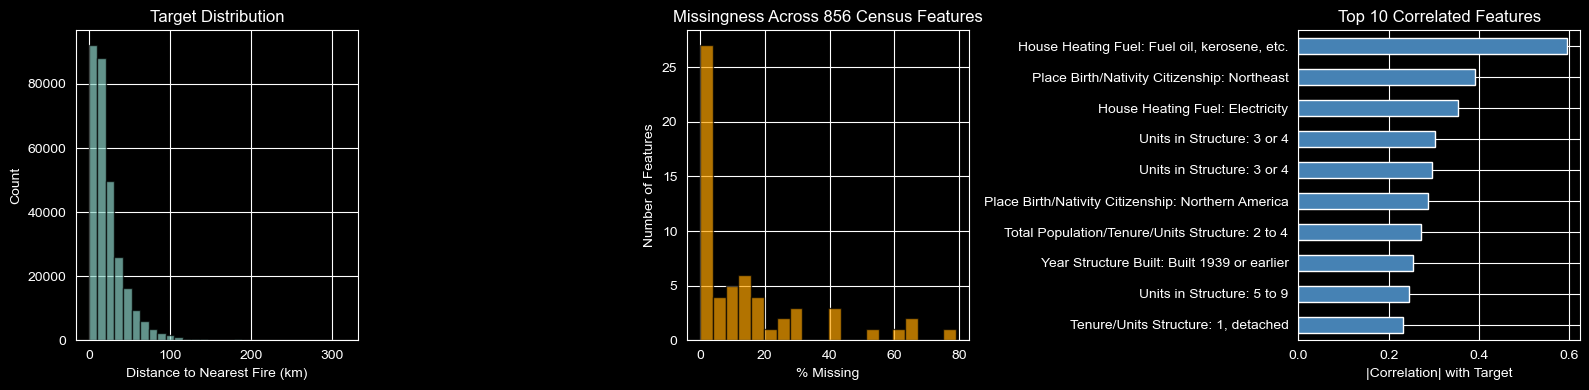


Dataset: 300000 properties, 869 columns
Census features: 856
Features with missing data: 60
Target range: 0.0 – 315.5 km


In [7]:
eda = visualize.eda(targets_features, target='nearest_fire_km')

In [ ]:
eda = visualize.eda(targets_features, target='exp_decay_score')


# Machine Learning Considerations

## Scoring Methods

**RMSE (Root Mean Squared Error)** is the primary metric. Its quadratic penalty on large errors aligns with the business case: underestimating wildfire risk (predicting a property is far from fires when it isn't) is costly for an insurance company. Because RMSE squares the residuals before averaging, a single prediction that is off by 50 km hurts the score far more than five predictions each off by 10 km — exactly the asymmetry we want when the cost of missing a high-risk property is much greater than slightly mispredicting a safe one.

**MAE (Mean Absolute Error)** complements RMSE by reporting the typical prediction error in the same units as the target (kilometres). Unlike RMSE, MAE weights every error linearly, so it is not dominated by outliers. Comparing the two is informative: when RMSE is much larger than MAE it signals that the model struggles with a tail of large-error cases. Here the gap is modest (~8.7 km RMSE vs ~6.2 km MAE), indicating reasonably consistent predictions without extreme outliers.

**R² (Coefficient of Determination)** measures the fraction of target variance explained by the model. An R² of 0.90 means census features alone capture 90% of the geographic variation in wildfire proximity — strong evidence that socioeconomic and housing patterns are meaningful proxies for fire exposure. R² is unit-free, making it useful for comparing across different target variables or datasets where the raw RMSE scale would differ.


# Data Preprocessing

## Split into Features/Targets and Preprocess

We use `nearest_fire_km` as the target — the distance in kilometres to the nearest wildfire detection. With the full 300k-property dataset, `exp_decay_score` (which captures both proximity and density of nearby fires) would be a better choice, but the small 119-property test set has nearly zero variance in decay score because all properties are ~360 km from the nearest fire.

All other proximity-derived columns are dropped so the model only sees census features as inputs.

*[TODO: Explain what Target range/std/mean are referring to here.]*


In [ ]:
TARGET_COL = "exp_decay_score"  #  "nearest_fire_km"

# All proximity features are derived from the same wildfire data — drop them
# so the model only sees census features as inputs.
drop_cols = ["geometry", "geoid"] + [c for c in proximity_cols if c != TARGET_COL]

# Subsample in test mode for fast iteration
ml_data = targets_features
if TEST_MODE:
    ml_data = targets_features.sample(n=TEST_SAMPLE_SIZE, random_state=77)
    print(f"TEST MODE: subsampled to {len(ml_data)} rows")


X_train, X_test, y_train, y_test, feature_names, pipeline = train.preprocess_with_cache(
    ml_data,
    TARGET_COL,
    drop_cols,
    nan_threshold=0.45,
    corr_threshold=0.85,
    mar_corr_threshold=0.1,
    use_cache=not TEST_MODE,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: {y_train.min():.4f} – {y_train.max():.4f}")
print(f"Target std:   {y_train.std():.6f}")
print(f"Target mean:  {y_train.mean():.4f}")

In [ ]:
# Diagnostic: check if the target has meaningful variance
cv = y_train.std() / y_train.mean() * 100  # coefficient of variation
print(f"Coefficient of variation: {cv:.4f}%")
if cv < 1.0:
    print(
        f"WARNING: Target has near-zero variance (CV={cv:.4f}%). "
        f"All properties are ~{y_train.mean():.1f} km from the nearest fire. "
        f"Models will appear to have perfect accuracy but are not learning meaningful patterns. "
        f"Scale to 300k properties for geographic diversity."
    )

# Model Training


due to the VRAM limitations of my local hardware (only 6GB of VRAM vs 32GB of regular RAM), I'll be training these models using the CPU with 10 jobs in parallel.

## Check for Previously Trained Models

In [ ]:
MODEL_DIR = PATH_MODELS
RFR_PATH = MODEL_DIR / f"rfr_model_{TARGET_COL}.pkl"
XGB_PATH = MODEL_DIR / f"xgb_model_{TARGET_COL}.pkl"

rfr_model, xgb_model = None, None

if not TEST_MODE:
    if RFR_PATH.exists():
        rfr_artifact = train.load_model(RFR_PATH)
        rfr_model = rfr_artifact["model"]
        print(f"Loaded RF model from {RFR_PATH}")
        rfr_metrics = train.evaluate_model(rfr_model, X_train, X_test, y_train, y_test)
        print(f"\nRF  Test RMSE: {rfr_metrics['test_rmse']:.4f}")

    if XGB_PATH.exists():
        xgb_artifact = train.load_model(XGB_PATH)
        xgb_model = xgb_artifact["model"]
        print(f"Loaded XGB model from {XGB_PATH}")
        xgb_metrics = train.evaluate_model(xgb_model, X_train, X_test, y_train, y_test)
        print(f"XGB Test RMSE: {xgb_metrics['test_rmse']:.4f}")

    else:
        print("No cached models found. Run the training cells below.")
else:
    print(f"TEST MODE: will train on {X_train.shape[0]} rows, "
          f"n_iter={TEST_N_ITER}, cv={TEST_CV}")

## Train Models

### RandomForestRegressor

*[TODO: Explain why the RFR is suitable.]* Takes about 1h20min on 2 cores

Train RMSE: 1340 with exp_decay_score
test RMSE : 1280 with exp_decay_score

In [ ]:
if rfr_model is None:
    n_iter = TEST_N_ITER if TEST_MODE else 20
    cv = TEST_CV if TEST_MODE else 5
    rfr_search = train.train_random_forest(X_train, y_train, n_iter=n_iter, cv=cv, n_jobs=10)
    rfr_model = rfr_search.best_estimator_
    print(f"Best RF params: {rfr_search.best_params_}")

    rfr_metrics = train.evaluate_model(rfr_model, X_train, X_test, y_train, y_test)
    if not TEST_MODE:
        train.save_model(rfr_model, RFR_PATH, pipeline=pipeline, feature_names=feature_names)
        print(f"Saved RF model to {RFR_PATH}")
else:
    print("RF model already loaded from cache.")

print(f"RF Train RMSE: {rfr_metrics['train_rmse']:.8f}")
print(f"RF Test  RMSE: {rfr_metrics['test_rmse']:.8f}")

### XGBoost
*[TODO: Explain why the XGB is suitable.]*


In [ ]:
if xgb_model is None:
    n_iter = TEST_N_ITER if TEST_MODE else 20
    cv = TEST_CV if TEST_MODE else 5
    xgb_search = train.train_xgboost(X_train, y_train, n_iter=n_iter, cv=cv, n_jobs=10)
    xgb_model = xgb_search.best_estimator_
    print(f"Best XGB params: {xgb_search.best_params_}")

    xgb_metrics = train.evaluate_model(xgb_model, X_train, X_test, y_train, y_test)
    if not TEST_MODE:
        train.save_model(xgb_model, XGB_PATH, pipeline=pipeline, feature_names=feature_names)
        print(f"Saved XGB model to {XGB_PATH}")
else:
    print("XGB model already loaded from cache.")

print(f"XGB Train RMSE: {xgb_metrics['train_rmse']:.8f}")
print(f"XGB Test  RMSE: {xgb_metrics['test_rmse']:.8f}")

## Model Comparison


- Very similar, RFR slightly better.
- Root mean squared error of about 8.5-9km, which is quite accurate considering the size of the contiguous USA.
- With my hardware, RFR model is faster to train on multiple CPU cores than XGBoost on GPU. and the final model is 40X larger on the hard disk, but not particularly oversized.
- The similarity between train and test RMSE suggests the data is not overfitting to the training data.
- The $R^2$~0.9 also suggests the model matches the observations quite well.


In [ ]:
comparison = pd.DataFrame({
    "RandomForest": train.full_metrics(rfr_model, X_train, X_test, y_train, y_test),
    "XGBoost": train.full_metrics(xgb_model, X_train, X_test, y_train, y_test),
})
comparison

In [ ]:
# Pick the better model
if xgb_metrics["test_rmse"] <= rfr_metrics["test_rmse"]:
    best_model = xgb_model
    print("Best model: XGBoost")
else:
    best_model = rfr_model
    print("Best model: RandomForest")
feature_names = [load_census.census_code_to_label(x) for x in feature_names]

## Best Model Visual Performance

- Clear linear relationship between predicted and actual distance to the nearest wildfire.
- There is some stratification in the predicted distance, which is likely due to the choice of granularity. A finer

In [ ]:
# Actual vs Predicted scatter plot
y_pred = best_model.predict(X_test)

fig_scatter = visualize.plot_actual_vs_predicted(
    y_test.values, 
    y_pred,
    title="Actual vs Predicted (Test Set)",
    xlabel="Actual Distance to Fire (km)",
    ylabel="Predicted Distance to Fire (km)",
    save_path=Path("figures/actual_vs_predicted.png")
)

## Feature Importance

*[TODO: Write 2-3 sentences interpreting the top features. What do the most important census features tell you about which neighborhoods are closer to wildfires? Do the results make intuitive sense?]*
- Matches the correlations EDA quite closely.
- Fossil fuel heated homes have the greatest weighting, following by having moved to a state from the Northeast.

In [ ]:
top_features = train.extract_feature_importance(best_model, feature_names, top_n=10)
print(f"\nTop 10 features:\n{top_features}")

In [ ]:
# Feature importance bar chart
fig_importance = visualize.plot_feature_importance(
    top_features,
    title="Top 10 Feature Importances",
    save_path=Path("figures/feature_importance.png")
)

In [ ]:
if not TEST_MODE:
    model_path = MODEL_DIR / "best_model.pkl"
    train.save_model(best_model, model_path, pipeline=pipeline, feature_names=feature_names)
    print(f"Best model saved to {model_path}")
else:
    print("TEST MODE: skipping model save.")

# Conclusion

*[TODO: Write your conclusion. Cover these points:]*

*1. **What did the model learn?** Can census features predict wildfire proximity? How well?*

*2. **Key findings:** Which feature groups mattered most? Any surprising predictors?*

*3. **Limitations:** Small sample size (119 properties), county-level granularity, single year of fire data, proximity != actual risk*

*4. **Business recommendation:** How would you use this model? What confidence level is needed before acting on predictions?*

*5. **Next steps:** Scale to 300k properties, add vegetation/weather/topography features, try finer geographic granularity, add a neural network model for comparison*